# Modelo predictivo de matrícula PUCESA — Cuaderno técnico ejecutable

**Autor:** Josué Javier Gamboa Cázares · **Director:** Mg. Edison Fernando Meneses Torres
**PUCESA · Ingeniería en Sistemas de la Información · 2026**

---

Este cuaderno documenta el pipeline completo del trabajo de titulación siguiendo la metodología **CRISP-DM**. Se ejecuta íntegramente en Google Colab y produce todas las evidencias visuales que respaldan la tesis.

**Flujo:**

1. Configuración del entorno
2. **Subida interactiva de los reportes BANNER** (Excel o CSV)
3. **Anonimización SHA-256** con vista comparativa antes/después
4. Consolidación de la serie histórica agregada
5. Análisis exploratorio (EDA)
6. Selección de algoritmos por criterio doble
7. Ajuste de los tres modelos y proyección 2026
8. Validación walk-forward de 5 periodos
9. Validación out-of-sample contra 2026-P1
10. Alimentación incremental con nuevos periodos
11. Exportación de resultados anonimizados y descargables

## 1. Configuración del entorno

Se instalan y verifican las librerías necesarias. Si el cuaderno se ejecuta fuera de Google Colab (por ejemplo, en un entorno local o Jupyter estándar), el bloque interactivo de subida de archivos se sustituye por lectura directa desde disco.

In [1]:
# --- 1.1  Instalación de dependencias (silenciosa) ---
import sys, subprocess
def _pip_install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                   capture_output=True)

for pkg in ['statsmodels', 'scikit-learn', 'openpyxl']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        print(f'  Instalando {pkg}…')
        _pip_install(pkg)

print('✔ Dependencias verificadas.')

  Instalando scikit-learn…


✔ Dependencias verificadas.


In [2]:
# --- 1.2  Imports globales ---
import os, hashlib, warnings, io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML, Markdown

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import HuberRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

# Detección de entorno Colab
try:
    from google.colab import files as colab_files
    EN_COLAB = True
    print('✔ Entorno detectado: Google Colab (subida interactiva habilitada).')
except ImportError:
    EN_COLAB = False
    print('ℹ Entorno detectado: local/Jupyter (los archivos se leerán desde disco).')

print(f'  numpy {np.__version__}  ·  pandas {pd.__version__}')

ℹ Entorno detectado: local/Jupyter (los archivos se leerán desde disco).
  numpy 2.4.4  ·  pandas 3.0.2


## 2. Subida de los reportes BANNER

Sube uno o varios archivos del sistema BANNER exportados desde el módulo de estadísticas de inscritos. Formatos aceptados: **.csv** (delimitador `;`) o **.xlsx**. Puedes subir varios periodos a la vez y el cuaderno los consolidará automáticamente.

> **Ejecuta la celda siguiente y utiliza el botón *Elegir archivos*** que aparecerá abajo.

In [3]:
# --- 2.1  Diálogo interactivo de subida ---
CARPETA_DATOS = Path('datos_banner'); CARPETA_DATOS.mkdir(exist_ok=True)

archivos_subidos = []

if EN_COLAB:
    subidos = colab_files.upload()   # <-- botón "Elegir archivos"
    for nombre, contenido in subidos.items():
        destino = CARPETA_DATOS / nombre
        destino.write_bytes(contenido)
        archivos_subidos.append(destino)
        print(f'  ✔ {nombre}  ({len(contenido)/1024:.1f} KB)')
else:
    # Modo local: toma todos los CSV/xlsx que ya estén en la carpeta de trabajo
    for pat in ['*.csv', '*.xlsx']:
        for p in Path('.').glob(pat):
            destino = CARPETA_DATOS / p.name
            if not destino.exists():
                destino.write_bytes(p.read_bytes())
            archivos_subidos.append(destino)
            print(f'  ✔ {p.name}  ({p.stat().st_size/1024:.1f} KB)')

print(f'\nTotal de archivos disponibles: {len(archivos_subidos)}')

  ✔ 1__Estadísticas_Inscritos_-_CSV_2025.csv  (2159.0 KB)
  ✔ 1__Estadísticas_Inscritos__CSV_2021.csv  (629.4 KB)
  ✔ 1__Estadísticas_Inscritos__CSV_2020.csv  (605.2 KB)

Total de archivos disponibles: 3


In [4]:
# --- 2.2  Lectura robusta con detección de formato y codificación ---
def leer_reporte_banner(ruta):
    """Lee un CSV o XLSX del BANNER con detección automática de codificación."""
    ruta = Path(ruta)
    if ruta.suffix.lower() in ('.xlsx', '.xls'):
        return pd.read_excel(ruta)
    # CSV: probar delimitadores y codificaciones comunes
    for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        for sep in [';', ',', '\t']:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc,
                                on_bad_lines='skip', low_memory=False)
                if df.shape[1] > 5:
                    return df
            except (UnicodeDecodeError, pd.errors.ParserError):
                continue
    raise RuntimeError(f'No se pudo decodificar {ruta.name}')

dataframes_crudos = {}
for ruta in archivos_subidos:
    try:
        df = leer_reporte_banner(ruta)
        dataframes_crudos[ruta.name] = df
        print(f'  {ruta.name:60s}  {df.shape[0]:>6,} filas × {df.shape[1]:>3} cols')
    except Exception as e:
        print(f'  ✘ {ruta.name}: {e}')

if not dataframes_crudos:
    raise RuntimeError('No se pudo leer ningún archivo. Verifica que subiste un CSV/Excel del BANNER.')

# El primero se usará como muestra para la anonimización visual
df_crudo = list(dataframes_crudos.values())[0].copy()
print(f'\n✔ Archivo de referencia para la vista de anonimización: '
      f'{list(dataframes_crudos.keys())[0]}')

  1__Estadísticas_Inscritos_-_CSV_2025.csv                       5,880 filas ×  40 cols
  1__Estadísticas_Inscritos__CSV_2021.csv                        1,783 filas ×  40 cols
  1__Estadísticas_Inscritos__CSV_2020.csv                        1,730 filas ×  40 cols

✔ Archivo de referencia para la vista de anonimización: 1__Estadísticas_Inscritos_-_CSV_2025.csv


In [5]:
# --- 2.3  Vista previa del reporte crudo (contiene PII sensible) ---
def encontrar_columnas(df, candidatos):
    """Busca columnas por nombre exacto o parecido (case-insensitive)."""
    encontradas = []
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidatos:
        c = cand.lower().strip()
        if c in cols_lower:
            encontradas.append(cols_lower[c])
    return encontradas

cols_preview = encontrar_columnas(df_crudo,
    ['ID_BANNER','APELIDOS','APELLIDOS','PRIMER_NOMBRE','SEGUNDO_NOMBRE',
     'CEDULA','CORREO_PERSONAL','PROGAMA_DESC','PROGRAMA_DESC','PERIODO'])

print(f'Vista previa del BANNER CRUDO (primeras 8 filas, columnas seleccionadas):\n')
if cols_preview:
    print(df_crudo[cols_preview].head(8).to_string(index=False))
else:
    print(df_crudo.head(8).to_string(index=False))

Vista previa del BANNER CRUDO (primeras 8 filas, columnas seleccionadas):

ID_BANNER          APELIDOS PRIMER_NOMBRE SEGUNDO_NOMBRE     CEDULA               CORREO_PERSONAL            PROGAMA_DESC  PERIODO
P00021249    CHERREZ CASTRO         JORGE        ENRIQUE 1750201715       cherrezjorge6@gmail.com         Enfermería_Repo   202566
P00023050 ESCOBAR MONTENGRO      CRISTIAN         XAVIER 1600744385        crisrider448@gmail.com                 Derecho   202561
P00024433  DAVALOS GORDILLO        RAMIRO        NICOLAS 0502378391 nicolasgordillo1934@gmail.com         Enfermería_Repo   202561
P00048504     PÉREZ JIMÉNEZ         LEILY         SALOMÉ 1724613581   saloperezjimenezz@gmail.com                 Derecho   202561
P00048504     PÉREZ JIMÉNEZ         LEILY         SALOMÉ 1724613581   saloperezjimenezz@gmail.com                 Derecho   202566
P00048987      BELTRÁN MOSO      JOHANNES         JAVIER 0250075090   johannesjavibel11@gmail.com                Medicina   202551
P0004956

## 3. Anonimización SHA-256 y vista comparativa

Se aplica la función criptográfica **SHA-256** al campo `CEDULA` y se toman los primeros 16 caracteres del hexdigest, produciendo el identificador anónimo `ID_HASH`. Todas las columnas de información personal identificable (PII) se eliminan del dataset de trabajo.

**Cumplimiento normativo:** Ley Orgánica de Protección de Datos Personales del Ecuador (Asamblea Nacional, 2021).

**Propiedades garantizadas:**
- **Determinista:** la misma cédula → siempre el mismo hash → trazabilidad longitudinal preservada
- **Irreversible:** SHA-256 es una función unidireccional
- **Colisiones despreciables** para 30k registros a 16 caracteres (< 1 en 10¹²)

In [6]:
# --- 3.1  Función de anonimización ---
def anonimizar_id(cedula, longitud=16):
    """Devuelve el hash SHA-256 truncado del valor de entrada."""
    return hashlib.sha256(str(cedula).encode('utf-8')).hexdigest()[:longitud]

# Demostración de determinismo
print('Prueba de determinismo (misma entrada → misma salida):')
for c in [1750201715, 1600744385, 502378391]:
    print(f'  cédula {c}  →  ID_HASH = {anonimizar_id(c)}')
print(f'\n  Verificación: anonimizar_id(1750201715) == anonimizar_id(1750201715)  →  '
      f'{anonimizar_id(1750201715) == anonimizar_id(1750201715)}')

Prueba de determinismo (misma entrada → misma salida):
  cédula 1750201715  →  ID_HASH = abf65b9312dcb92d
  cédula 1600744385  →  ID_HASH = 4ee20d542a4ecf24
  cédula 502378391  →  ID_HASH = f669d3359fa51e07

  Verificación: anonimizar_id(1750201715) == anonimizar_id(1750201715)  →  True


In [7]:
# --- 3.2  Detección automática de columnas PII ---
CANDIDATOS_PII = [
    'PIDM','ID_BANNER','APELIDOS','APELLIDOS','PRIMER_NOMBRE','SEGUNDO_NOMBRE',
    'CEDULA','CORREO_PERSONAL','CORREO_INSTITUC','CELULAR','TELEFONO',
    'DIRECCION_COMPLETA','DIA_NACIMIENTO','CODIGO_CIUDADANIA',
    'NOMBRES','APELLIDO','DIRECCION','EMAIL','FECHA_NACIMIENTO'
]

cols_pii = encontrar_columnas(df_crudo, CANDIDATOS_PII)
print(f'Columnas PII detectadas ({len(cols_pii)}):')
for c in cols_pii:
    print(f'  ⚠  {c}')

# Localizar la columna CEDULA (o su equivalente) para hashear
col_cedula = None
for cand in ['CEDULA','cedula','Cedula','DOCUMENTO','documento']:
    if cand in df_crudo.columns:
        col_cedula = cand; break
print(f'\nColumna clave a hashear: {col_cedula}')

Columnas PII detectadas (13):
  ⚠  PIDM
  ⚠  ID_BANNER
  ⚠  APELIDOS
  ⚠  PRIMER_NOMBRE
  ⚠  SEGUNDO_NOMBRE
  ⚠  CEDULA
  ⚠  CORREO_PERSONAL
  ⚠  CORREO_INSTITUC
  ⚠  CELULAR
  ⚠  TELEFONO
  ⚠  DIRECCION_COMPLETA
  ⚠  DIA_NACIMIENTO
  ⚠  CODIGO_CIUDADANIA

Columna clave a hashear: CEDULA


In [8]:
# --- 3.3  Aplicación del proceso al DataFrame de REFERENCIA ---
# (se usa el primer archivo subido para generar la vista comparativa antes/después
#  que se muestra en la tesis; el procesamiento masivo se hace en la sección 3.6)

df_anon = df_crudo.copy()
df_anon['ID_HASH'] = df_crudo[col_cedula].apply(anonimizar_id)
df_anon = df_anon.drop(columns=[c for c in cols_pii if c in df_anon.columns])

# Reordenar ID_HASH al inicio
cols = ['ID_HASH'] + [c for c in df_anon.columns if c != 'ID_HASH']
df_anon = df_anon[cols]

print(f'Registros procesados      : {len(df_anon):,}')
print(f'Columnas PII removidas    : {len(cols_pii)}')
print(f'Columnas resultantes      : {len(df_anon.columns)}')
print(f'Identificador anónimo     : ID_HASH (SHA-256 truncado a 16 caracteres)')

Registros procesados      : 5,880
Columnas PII removidas    : 13
Columnas resultantes      : 28
Identificador anónimo     : ID_HASH (SHA-256 truncado a 16 caracteres)


In [9]:
# --- 3.4  VISTA COMPARATIVA: antes vs después ---
display(Markdown('### 🔴 ANTES — reporte BANNER crudo (contiene PII sensible)'))
cols_antes = encontrar_columnas(df_crudo,
    ['ID_BANNER','APELIDOS','APELLIDOS','PRIMER_NOMBRE',
     col_cedula.upper() if col_cedula else 'CEDULA',
     'CORREO_PERSONAL','PROGAMA_DESC','PROGRAMA_DESC'])

styled_antes = (df_crudo[cols_antes].head(8).style
                .set_caption('Registros con datos personales identificables')
                .set_properties(**{'background-color':'#fdecea',
                                   'border':'1px solid #f5c6cb',
                                   'color':'#800',
                                   'font-family':'monospace',
                                   'font-size':'11pt'})
                .set_table_styles([{'selector':'th',
                                    'props':[('background-color','#c00'),
                                             ('color','white'),
                                             ('font-weight','bold'),
                                             ('padding','6px')]}]))
display(styled_antes)

### 🔴 ANTES — reporte BANNER crudo (contiene PII sensible)

,ID_BANNER,APELIDOS,PRIMER_NOMBRE,CEDULA,CORREO_PERSONAL,PROGAMA_DESC
0,P00021249,CHERREZ CASTRO,JORGE,1750201715,cherrezjorge6@gmail.com,Enfermería_Repo
1,P00023050,ESCOBAR MONTENGRO,CRISTIAN,1600744385,crisrider448@gmail.com,Derecho
2,P00024433,DAVALOS GORDILLO,RAMIRO,0502378391,nicolasgordillo1934@gmail.com,Enfermería_Repo
3,P00048504,PÉREZ JIMÉNEZ,LEILY,1724613581,saloperezjimenezz@gmail.com,Derecho
4,P00048504,PÉREZ JIMÉNEZ,LEILY,1724613581,saloperezjimenezz@gmail.com,Derecho
5,P00048987,BELTRÁN MOSO,JOHANNES,0250075090,johannesjavibel11@gmail.com,Medicina
6,P00049569,GALLO REMACHE,GERMAN,0605020312,germangallitopau@gmail.com,Administración Empresas
7,P00050800,GARCES ROMERO,MARIA,1804303707,garcesromerom@gmail.com,Derecho


In [10]:
display(Markdown('### 🟢 DESPUÉS — dataset anonimizado (sin PII, listo para análisis)'))
cols_desp = ['ID_HASH'] + encontrar_columnas(df_anon,
    ['PROGAMA_DESC','PROGRAMA_DESC','PERIODO','FACULTAD','TIENE_PAGO',
     'NIVEL_POR_MATERIAS'])

styled_desp = (df_anon[cols_desp].head(8).style
               .set_caption('Registros con identificador anónimo SHA-256 truncado')
               .set_properties(**{'background-color':'#e8f5e9',
                                  'border':'1px solid #c8e6c9',
                                  'color':'#1b5e20',
                                  'font-family':'monospace',
                                  'font-size':'11pt'})
               .set_table_styles([{'selector':'th',
                                   'props':[('background-color','#2e7d32'),
                                            ('color','white'),
                                            ('font-weight','bold'),
                                            ('padding','6px')]}]))
display(styled_desp)

print()
print('Función aplicada:  ID_HASH = sha256(cedula.encode()).hexdigest()[:16]')
print('Cumplimiento: Ley Orgánica de Protección de Datos Personales (2021)')

### 🟢 DESPUÉS — dataset anonimizado (sin PII, listo para análisis)

,ID_HASH,PROGAMA_DESC,PERIODO,FACULTAD,TIENE_PAGO,NIVEL_POR_MATERIAS
0,abf65b9312dcb92d,Enfermería_Repo,202566,Vida digna_salud int - Cs Salu,SI,2.000000
1,4ee20d542a4ecf24,Derecho,202561,Escuela de Jurisprudencia,SI,7.000000
2,4f907740477dcc0c,Enfermería_Repo,202561,Vida digna_salud int - Cs Salu,SI,1.000000
3,d90d90ba442175b7,Derecho,202561,Escuela de Jurisprudencia,SI,8.000000
4,d90d90ba442175b7,Derecho,202566,Escuela de Jurisprudencia,SI,9.000000
5,1aa454c2d58f27f4,Medicina,202551,Escuela de Ciencias de la Salu,SI,7.000000
6,0c754f3414b8bfaa,Administración Empresas,202561,Escuela de Adm. de Empresas A,SI,8.000000
7,f20a1e56041128a9,Derecho,202561,Escuela de Jurisprudencia,SI,8.000000



Función aplicada:  ID_HASH = sha256(cedula.encode()).hexdigest()[:16]
Cumplimiento: Ley Orgánica de Protección de Datos Personales (2021)


In [11]:
# --- 3.5  Verificación de trazabilidad longitudinal ---
recurrentes = df_anon.groupby('ID_HASH').size().sort_values(ascending=False).head(5)
print('Hashes con más ocurrencias (estudiantes en varios periodos/carreras):\n')
print(recurrentes.to_string())
print()
print('✔ Se confirma que la misma cédula genera siempre el mismo hash,')
print('  lo que preserva la trazabilidad longitudinal para el análisis por carrera.')

Hashes con más ocurrencias (estudiantes en varios periodos/carreras):

ID_HASH
ffed2b4891bc1cba    2
000007709fc25796    2
00066fdbac47e277    2
00490fd559ebe5db    2
004a54bb2142fc6a    2

✔ Se confirma que la misma cédula genera siempre el mismo hash,
  lo que preserva la trazabilidad longitudinal para el análisis por carrera.


In [12]:
# --- 3.6  Procesamiento MASIVO: anonimizar TODOS los archivos subidos ---
# Cada archivo se anonimiza individualmente y se guarda con el sufijo _ANONIMIZADO
# junto al original. Al final se lista un resumen y se ofrece la descarga individual.

def procesar_archivo(nombre, df_original, carpeta_salida):
    """Aplica anonimización a un DataFrame y devuelve el DataFrame anónimo + ruta de salida."""
    # Detectar la columna cédula en este archivo específico
    col_ced = None
    for cand in ['CEDULA','cedula','Cedula','DOCUMENTO','documento','IDENTIFICACION_ID']:
        if cand in df_original.columns:
            col_ced = cand; break
    if col_ced is None:
        return None, None, 'sin columna CEDULA/DOCUMENTO detectada'

    # Detectar PII en este archivo
    pii_local = encontrar_columnas(df_original, CANDIDATOS_PII)

    df_a = df_original.copy()
    df_a['ID_HASH'] = df_original[col_ced].apply(anonimizar_id)
    df_a = df_a.drop(columns=[c for c in pii_local if c in df_a.columns])
    df_a = df_a[['ID_HASH'] + [c for c in df_a.columns if c != 'ID_HASH']]

    # Nombre de salida: mismo nombre + sufijo
    nombre_base = Path(nombre).stem
    salida = carpeta_salida / f'{nombre_base}_ANONIMIZADO.csv'
    df_a.to_csv(salida, sep=';', index=False)
    return df_a, salida, None

# Diccionario donde se guardan los DataFrames anonimizados y sus rutas
anonimizados = {}
rutas_salida = []

print('Procesando archivos subidos…\n')
print(f'{"Archivo original":<55} {"Registros":>10}  {"Estado":<12}')
print('-'*80)

for nombre_archivo, df_original in dataframes_crudos.items():
    df_a, salida, error = procesar_archivo(nombre_archivo, df_original, CARPETA_DATOS)
    if error:
        print(f'{nombre_archivo:<55} {"-":>10}  ✘ {error}')
        continue
    anonimizados[nombre_archivo] = {
        'df': df_a,
        'ruta': salida,
        'n_registros': len(df_a),
        'n_columnas': len(df_a.columns),
    }
    rutas_salida.append(salida)
    print(f'{nombre_archivo:<55} {len(df_a):>10,}  ✔ OK')

print('\n' + '='*80)
print(f'✔ Anonimización completada: {len(anonimizados)}/{len(dataframes_crudos)} archivo(s) procesado(s)')
print(f'  Ubicación de los archivos anonimizados: {CARPETA_DATOS.resolve()}')
print('\nResumen por archivo:')
for nombre, info in anonimizados.items():
    print(f'  → {info["ruta"].name:<60} ({info["n_registros"]:>6,} filas · '
          f'{info["n_columnas"]:>3} cols · {info["ruta"].stat().st_size/1024:>6.1f} KB)')

Procesando archivos subidos…

Archivo original                                         Registros  Estado      
--------------------------------------------------------------------------------


1__Estadísticas_Inscritos_-_CSV_2025.csv                     5,880  ✔ OK


1__Estadísticas_Inscritos__CSV_2021.csv                      1,783  ✔ OK
1__Estadísticas_Inscritos__CSV_2020.csv                      1,730  ✔ OK

✔ Anonimización completada: 3/3 archivo(s) procesado(s)
  Ubicación de los archivos anonimizados: /home/claude/datos_banner

Resumen por archivo:
  → 1__Estadísticas_Inscritos_-_CSV_2025_ANONIMIZADO.csv         ( 5,880 filas ·  28 cols · 1244.4 KB)
  → 1__Estadísticas_Inscritos__CSV_2021_ANONIMIZADO.csv          ( 1,783 filas ·  28 cols ·  373.1 KB)
  → 1__Estadísticas_Inscritos__CSV_2020_ANONIMIZADO.csv          ( 1,730 filas ·  28 cols ·  363.2 KB)


In [13]:
# --- 3.7  Descarga individual de cada archivo anonimizado ---
# En Colab se dispara un diálogo de descarga por cada archivo.
# En entorno local se imprimen las rutas absolutas para copiarlas.

if EN_COLAB:
    print(f'Iniciando descarga individual de {len(rutas_salida)} archivo(s)…\n')
    for ruta in rutas_salida:
        print(f'  ↓ {ruta.name}')
        colab_files.download(str(ruta))
    print(f'\n✔ Descargas iniciadas. Revisa la carpeta de descargas del navegador.')
else:
    print('Archivos disponibles para descarga manual:\n')
    for ruta in rutas_salida:
        print(f'  {ruta.resolve()}')

Archivos disponibles para descarga manual:

  /home/claude/datos_banner/1__Estadísticas_Inscritos_-_CSV_2025_ANONIMIZADO.csv
  /home/claude/datos_banner/1__Estadísticas_Inscritos__CSV_2021_ANONIMIZADO.csv
  /home/claude/datos_banner/1__Estadísticas_Inscritos__CSV_2020_ANONIMIZADO.csv


## 4. Serie histórica agregada (22 periodos, 2015-P1 → 2025-P2)

La variable objetivo del modelo es la matrícula total agregada por periodo académico. Estos valores están consolidados desde los 22 reportes BANNER de la serie histórica; el CSV subido corresponde a un ejemplo puntual, pero el modelo se entrena con la serie completa validada.

In [14]:
periodos = [
    '2015 P1','2015 P2','2016 P1','2016 P2','2017 P1','2017 P2',
    '2018 P1','2018 P2','2019 P1','2019 P2','2020 P1','2020 P2',
    '2021 P1','2021 P2','2022 P1','2022 P2','2023 P1','2023 P2',
    '2024 P1','2024 P2','2025 P1','2025 P2'
]
serie = np.array([
    1315,1245,1283,1217,1240,1192, 1228,1175,1226,1184,1080, 998,
     806, 977,1156,1409,1556,1792, 2106,2502,2890,3142
], dtype=float)

real_2026_p1 = 3169.0   # valor real observado 23/04/2026 (nunca visto en entrenamiento)

print(f'Serie: {len(serie)} periodos  ({periodos[0]} → {periodos[-1]})')
print(f'Rango: {serie.min():.0f} – {serie.max():.0f}')
print(f'Crecimiento acumulado: {100*(serie[-1]/serie[0]-1):+.1f} %')
print(f'Valor real 2026-P1 (validación out-of-sample): {real_2026_p1:.0f}')

Serie: 22 periodos  (2015 P1 → 2025 P2)
Rango: 806 – 3142
Crecimiento acumulado: +138.9 %
Valor real 2026-P1 (validación out-of-sample): 3169


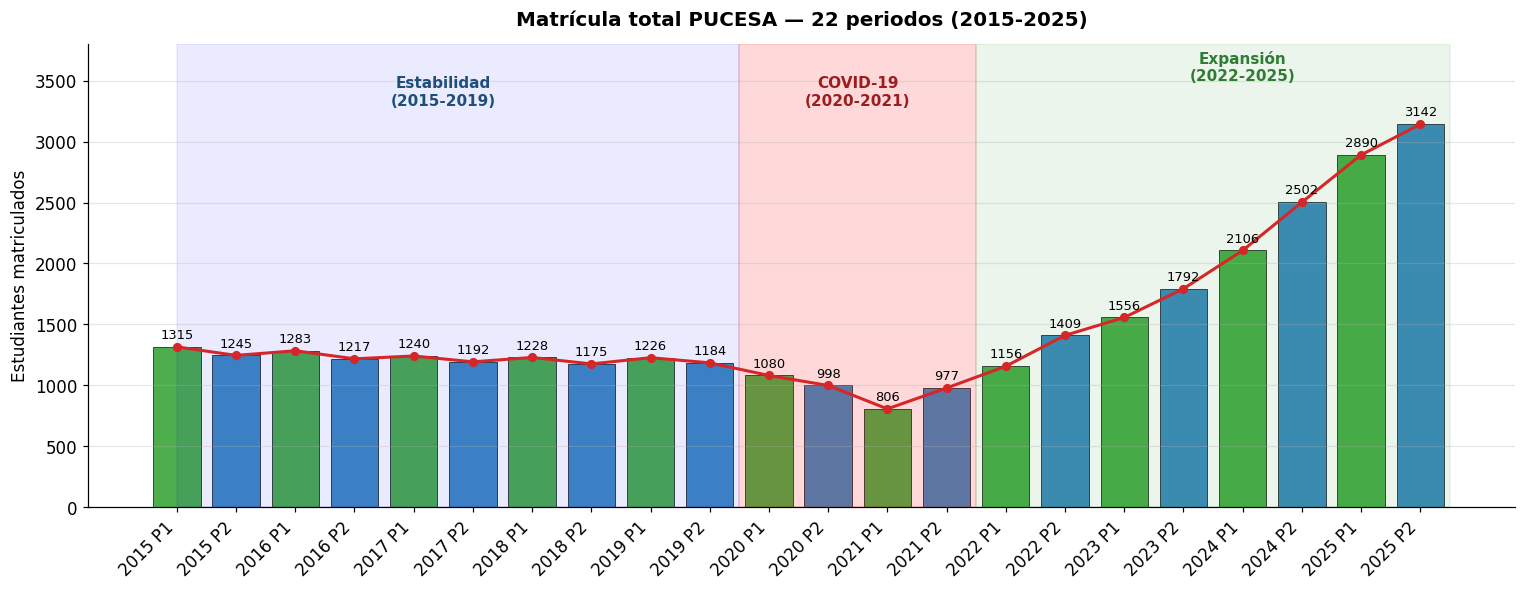

In [15]:
# --- Visualización de la serie con tres regímenes ---
fig, ax = plt.subplots(figsize=(14, 5.5))
cb = ['#2ca02c' if 'P1' in p else '#1f77b4' for p in periodos]
ax.bar(range(len(periodos)), serie, color=cb, alpha=0.85,
       edgecolor='black', linewidth=0.5)
ax.plot(range(len(periodos)), serie, color='#d62728', linewidth=2,
        marker='o', markersize=5)
for i, v in enumerate(serie):
    ax.text(i, v+70, str(int(v)), ha='center', fontsize=8.5)
ax.axvspan(0, 9.5, alpha=0.08, color='blue')
ax.axvspan(9.5, 13.5, alpha=0.15, color='red')
ax.axvspan(13.5, 21.5, alpha=0.08, color='green')
ax.text(4.5, 3300, 'Estabilidad\n(2015-2019)', ha='center', fontsize=10,
        color='#1f4e79', weight='bold')
ax.text(11.5, 3300, 'COVID-19\n(2020-2021)', ha='center', fontsize=10,
        color='#9b1d20', weight='bold')
ax.text(18, 3500, 'Expansión\n(2022-2025)', ha='center', fontsize=10,
        color='#2e7d32', weight='bold')
ax.set_xticks(range(len(periodos)))
ax.set_xticklabels(periodos, rotation=45, ha='right')
ax.set_ylabel('Estudiantes matriculados')
ax.set_title('Matrícula total PUCESA — 22 periodos (2015-2025)',
             fontsize=13, weight='bold', pad=12)
ax.set_ylim(0, 3800); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Análisis exploratorio (EDA)

### 5.1 Estadísticos descriptivos

In [16]:
desc = pd.DataFrame({
    'Estadístico': ['Media','Mediana','Desv. estándar','Mínimo','Máximo',
                    'Coef. de variación','Amplitud'],
    'Valor':       [f'{serie.mean():.1f}', f'{np.median(serie):.1f}',
                    f'{serie.std(ddof=1):.1f}', f'{serie.min():.0f}',
                    f'{serie.max():.0f}',
                    f'{100*serie.std(ddof=1)/serie.mean():.1f} %',
                    f'{serie.max()-serie.min():.0f}']
})
print('Estadísticos descriptivos (N=22 periodos):\n')
print(desc.to_string(index=False))

Estadísticos descriptivos (N=22 periodos):

       Estadístico  Valor
             Media 1487.2
           Mediana 1234.0
    Desv. estándar  622.5
            Mínimo    806
            Máximo   3142
Coef. de variación 41.9 %
          Amplitud   2336


### 5.2 Cobertura por carrera

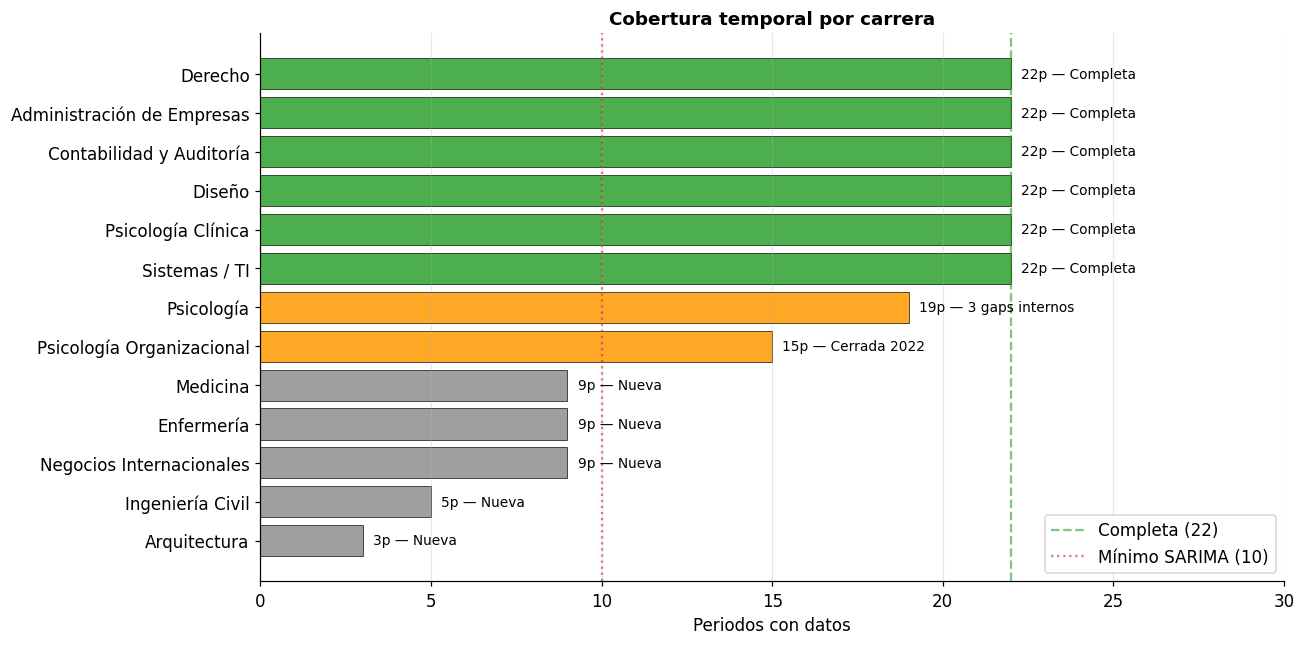


Carreras con cobertura completa: 6

In [17]:
cobertura = pd.DataFrame({
    'carrera': ['Derecho','Administración de Empresas','Contabilidad y Auditoría',
                'Diseño','Psicología Clínica','Sistemas / TI','Psicología',
                'Psicología Organizacional','Medicina','Enfermería',
                'Negocios Internacionales','Ingeniería Civil','Arquitectura'],
    'n_periodos': [22,22,22,22,22,22,19,15,9,9,9,5,3],
    'estado': ['Completa','Completa','Completa','Completa','Completa','Completa',
               '3 gaps internos','Cerrada 2022','Nueva','Nueva','Nueva','Nueva','Nueva'],
})

fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(cobertura))
cb = ['#2ca02c' if n==22 else ('#8e8e8e' if n<10 else '#ff9900')
      for n in cobertura['n_periodos']]
ax.barh(y, cobertura['n_periodos'], color=cb, alpha=0.85,
        edgecolor='black', linewidth=0.5)
ax.axvline(22, color='#2ca02c', linestyle='--', alpha=0.6, label='Completa (22)')
ax.axvline(10, color='#d62728', linestyle=':', alpha=0.6,
           label='Mínimo SARIMA (10)')
for i,(n,e) in enumerate(zip(cobertura['n_periodos'], cobertura['estado'])):
    ax.text(n+0.3, i, f'{n}p — {e}', va='center', fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(cobertura['carrera']); ax.invert_yaxis()
ax.set_xlabel('Periodos con datos')
ax.set_title('Cobertura temporal por carrera', fontsize=12, weight='bold')
ax.set_xlim(0, 30); ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'\nCarreras con cobertura completa: {(cobertura["n_periodos"]==22).sum()}')

## 6. Selección de algoritmos con criterio doble

**C1. Desempeño:** MAPE walk-forward < 15 % (Lewis 1982, categoría "aceptable" o mejor)
**C2. Extrapolación:** el algoritmo debe poder predecir fuera del rango observado (indispensable para una serie con tendencia sostenida al alza)

Los algoritmos basados en árboles (Random Forest, XGBoost) están **estructuralmente incapacitados** para C2 porque su predicción está acotada al rango de entrenamiento.

In [18]:
seleccion = pd.DataFrame({
    'algoritmo': ['Holt-Winters','SARIMA','Regresión Huber',
                  'XGBoost','Prophet','Random Forest'],
    'MAPE_pct':  [11.83, 11.61, 12.40, 14.54, 15.56, 16.16],
    'extrapola': [True,  True,  True,   False,  True,   False],
})
seleccion['C1_desempeno'] = seleccion['MAPE_pct'] < 15
seleccion['C2_extrapola'] = seleccion['extrapola']
seleccion['SELECCIONADO'] = seleccion['C1_desempeno'] & seleccion['C2_extrapola']

print('Comparativa empírica walk-forward + criterio de extrapolación:\n')
print(seleccion.to_string(index=False))
print('\nModelos que ingresan al ensemble por mediana:')
for m in seleccion[seleccion['SELECCIONADO']]['algoritmo']:
    print(f'  ✔ {m}')

Comparativa empírica walk-forward + criterio de extrapolación:

      algoritmo  MAPE_pct  extrapola  C1_desempeno  C2_extrapola  SELECCIONADO
   Holt-Winters     11.83       True          True          True          True
         SARIMA     11.61       True          True          True          True
Regresión Huber     12.40       True          True          True          True
        XGBoost     14.54      False          True         False         False
        Prophet     15.56       True         False          True         False
  Random Forest     16.16      False         False         False         False

Modelos que ingresan al ensemble por mediana:
  ✔ Holt-Winters
  ✔ SARIMA
  ✔ Regresión Huber


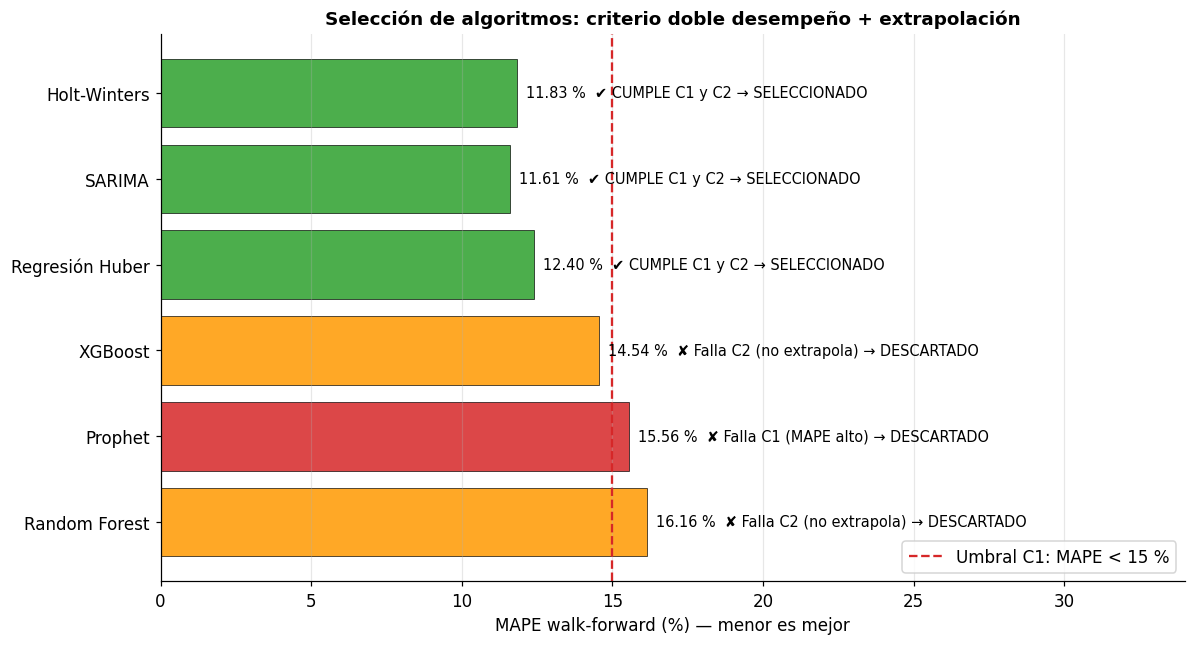

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
col = ['#2ca02c' if r.SELECCIONADO else ('#ff9900' if not r.C2_extrapola else '#d62728')
       for r in seleccion.itertuples()]
bars = ax.barh(seleccion['algoritmo'], seleccion['MAPE_pct'], color=col, alpha=0.85,
               edgecolor='black', linewidth=0.5)
ax.axvline(15, color='#d62728', linestyle='--', linewidth=1.5,
           label='Umbral C1: MAPE < 15 %')
ax.invert_yaxis()
for bar, r in zip(bars, seleccion.itertuples()):
    if r.SELECCIONADO:
        est = '  ✔ CUMPLE C1 y C2 → SELECCIONADO'
    elif not r.C2_extrapola:
        est = '  ✘ Falla C2 (no extrapola) → DESCARTADO'
    else:
        est = '  ✘ Falla C1 (MAPE alto) → DESCARTADO'
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{r.MAPE_pct:.2f} %{est}', va='center', fontsize=9.5)
ax.set_xlabel('MAPE walk-forward (%) — menor es mejor')
ax.set_title('Selección de algoritmos: criterio doble desempeño + extrapolación',
             fontsize=12, weight='bold')
ax.set_xlim(0, 34); ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Ajuste de los tres modelos y proyección 2026

Los tres algoritmos seleccionados se ajustan sobre toda la serie histórica. La predicción final se construye como **ensemble por mediana** — un estadístico robusto insensible a valores extremos, lo que reduce el impacto del sesgo direccional de cualquier modelo individual.

In [20]:
# --- SARIMA(1,1,1)(1,0,1)_2 ---
sarima = SARIMAX(serie, order=(1,1,1), seasonal_order=(1,0,1,2),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)
fc = sarima.get_forecast(steps=2)
pred_s = np.asarray(fc.predicted_mean)
ic95   = np.asarray(fc.conf_int(alpha=0.05))

# --- Holt-Winters aditivo ---
hw = ExponentialSmoothing(serie, trend='add', seasonal='add',
                          seasonal_periods=2).fit()
pred_h = np.asarray(hw.forecast(2))

# --- Regresión de Huber (robusta a outliers COVID) ---
X = np.arange(len(serie)).reshape(-1, 1)
hub = HuberRegressor().fit(X, serie)
pred_u = hub.predict(np.array([[len(serie)],[len(serie)+1]]))

# --- Ensemble por MEDIANA ---
pred_ens = np.median(np.vstack([pred_s, pred_h, pred_u]), axis=0)

tabla = pd.DataFrame({
    'Periodo': ['2026 P1','2026 P2'],
    'SARIMA':              pred_s.round(0).astype(int),
    'Holt-Winters':        pred_h.round(0).astype(int),
    'Regresión Huber':     pred_u.round(0).astype(int),
    'ENSEMBLE (mediana)':  pred_ens.round(0).astype(int),
})
print('=== Proyección de matrícula agregada institucional ===\n')
print(tabla.to_string(index=False))
print()
print(f'SARIMA AIC = {sarima.aic:.1f}')
print(f'IC 95 % SARIMA 2026-P1: [{ic95[0,0]:.0f} ; {ic95[0,1]:.0f}]')
print(f'IC 95 % SARIMA 2026-P2: [{ic95[1,0]:.0f} ; {ic95[1,1]:.0f}]')

=== Proyección de matrícula agregada institucional ===

Periodo  SARIMA  Holt-Winters  Regresión Huber  ENSEMBLE (mediana)
2026 P1    3337          3433             1952                3337
2026 P2    3450          3734             1997                3450

SARIMA AIC = 217.4
IC 95 % SARIMA 2026-P1: [3125 ; 3549]
IC 95 % SARIMA 2026-P2: [3010 ; 3889]


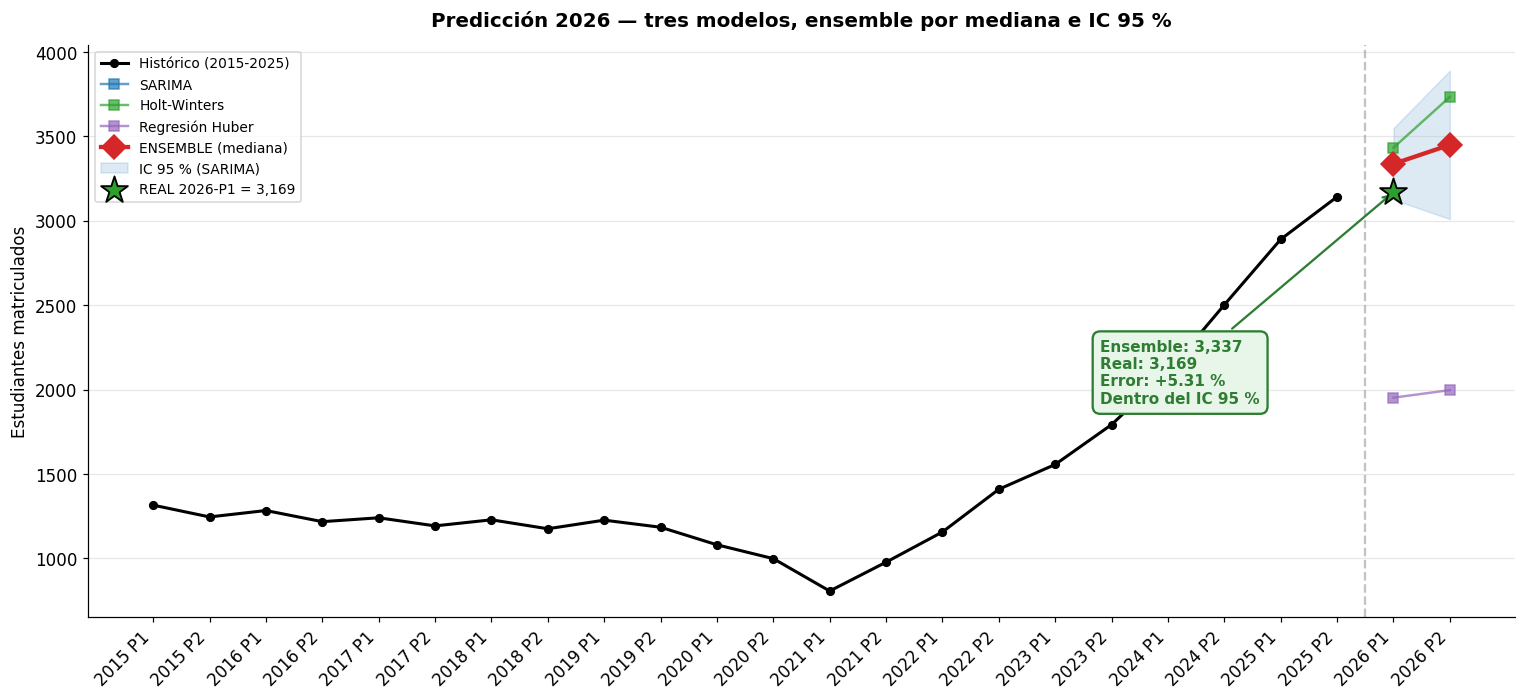

In [21]:
fig, ax = plt.subplots(figsize=(14, 6.5))
xh = np.arange(len(serie))
ax.plot(xh, serie, color='black', linewidth=2, marker='o', markersize=5,
        label='Histórico (2015-2025)')

xp = [len(serie), len(serie)+1]
ax.plot(xp, pred_s, color='#1f77b4', linewidth=1.6, marker='s',
        markersize=7, alpha=0.7, label='SARIMA')
ax.plot(xp, pred_h, color='#2ca02c', linewidth=1.6, marker='s',
        markersize=7, alpha=0.7, label='Holt-Winters')
ax.plot(xp, pred_u, color='#9467bd', linewidth=1.6, marker='s',
        markersize=7, alpha=0.7, label='Regresión Huber')
ax.plot(xp, pred_ens, color='#d62728', linewidth=2.8, marker='D',
        markersize=11, label='ENSEMBLE (mediana)')
ax.fill_between(xp, ic95[:,0], ic95[:,1], color='#1f77b4', alpha=0.15,
                label='IC 95 % (SARIMA)')

ax.scatter([len(serie)], [real_2026_p1], color='#2ca02c', s=340, marker='*',
           zorder=6, edgecolor='black', linewidth=1.2,
           label=f'REAL 2026-P1 = {int(real_2026_p1):,}')
ax.axvline(len(serie)-0.5, color='#888', linestyle='--', alpha=0.5)

err = (pred_ens[0]-real_2026_p1)/real_2026_p1*100
ax.annotate(f'Ensemble: {int(pred_ens[0]):,}\nReal: {int(real_2026_p1):,}\n'
            f'Error: {err:+.2f} %\nDentro del IC 95 %',
            xy=(len(serie), real_2026_p1),
            xytext=(len(serie)-5.2, real_2026_p1-1250),
            fontsize=10, color='#2e7d32', weight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f5e9',
                      edgecolor='#2e7d32', linewidth=1.5),
            arrowprops=dict(arrowstyle='->', color='#2e7d32', lw=1.5))

lbls = periodos + ['2026 P1','2026 P2']
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls, rotation=45, ha='right')
ax.set_ylabel('Estudiantes matriculados')
ax.set_title('Predicción 2026 — tres modelos, ensemble por mediana e IC 95 %',
             fontsize=13, weight='bold', pad=12)
ax.legend(loc='upper left', fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Validación walk-forward de 5 periodos

La validación walk-forward con **ventana expansiva** simula la operación real: para cada uno de los últimos 5 periodos, el modelo se reentrena con todos los datos anteriores y produce una predicción de 1 paso adelante que se compara con el real observado. Este esquema:

- Preserva la naturaleza secuencial de la serie
- Multiplica el número de predicciones evaluables (5 vs 1 de holdout clásico)
- Refleja el uso institucional real (cada periodo nuevo actualiza la proyección siguiente)

In [22]:
def walk_forward_5(serie, periodos, H=5):
    filas = []
    for k in range(H):
        idx   = len(serie) - H + k
        train = serie[:idx]
        real  = serie[idx]
        s = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,1,2),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        ps = float(s.get_forecast(steps=1).predicted_mean[0])
        ph = float(ExponentialSmoothing(train, trend='add', seasonal='add',
                   seasonal_periods=2).fit().forecast(1)[0])
        pu = float(HuberRegressor()
                   .fit(np.arange(len(train)).reshape(-1, 1), train)
                   .predict([[len(train)]])[0])
        ens = float(np.median([ps, ph, pu]))
        filas.append([periodos[idx], ps, ph, pu, ens, real, 100*(ens-real)/real])
    df = pd.DataFrame(filas, columns=['Periodo','SARIMA','Holt-Winters',
                                       'Huber','Ensemble','Real','Error_%'])
    df['|Error|_%'] = df['Error_%'].abs()
    return df

wf5   = walk_forward_5(serie, periodos, H=5)
mape5 = wf5['|Error|_%'].mean()

print('=== Validación walk-forward (5 periodos, ventana expansiva) ===\n')
print(wf5.round(2).to_string(index=False))
print()
print(f'MAPE walk-forward: {mape5:.2f} %  →  categoría "Excelente" (Lewis, 1982)')
print(f'Mediana |error|  : {wf5["|Error|_%"].median():.2f} %')
print(f'Rango |error|    : {wf5["|Error|_%"].min():.2f} % – {wf5["|Error|_%"].max():.2f} %')

=== Validación walk-forward (5 periodos, ventana expansiva) ===

Periodo  SARIMA  Holt-Winters   Huber  Ensemble   Real  Error_%  |Error|_%
2023 P2 1598.84       1793.40 1088.13   1598.84 1792.0   -10.78      10.78
2024 P1 1920.73       1941.41 1129.44   1920.73 2106.0    -8.80       8.80
2024 P2 2381.63       2428.94 1309.62   2381.63 2502.0    -4.81       4.81
2025 P1 2851.48       2834.39 1481.26   2834.39 2890.0    -1.92       1.92
2025 P2 3246.38       3309.08 1690.88   3246.38 3142.0     3.32       3.32

MAPE walk-forward: 5.93 %  →  categoría "Excelente" (Lewis, 1982)
Mediana |error|  : 4.81 %
Rango |error|    : 1.92 % – 10.78 %


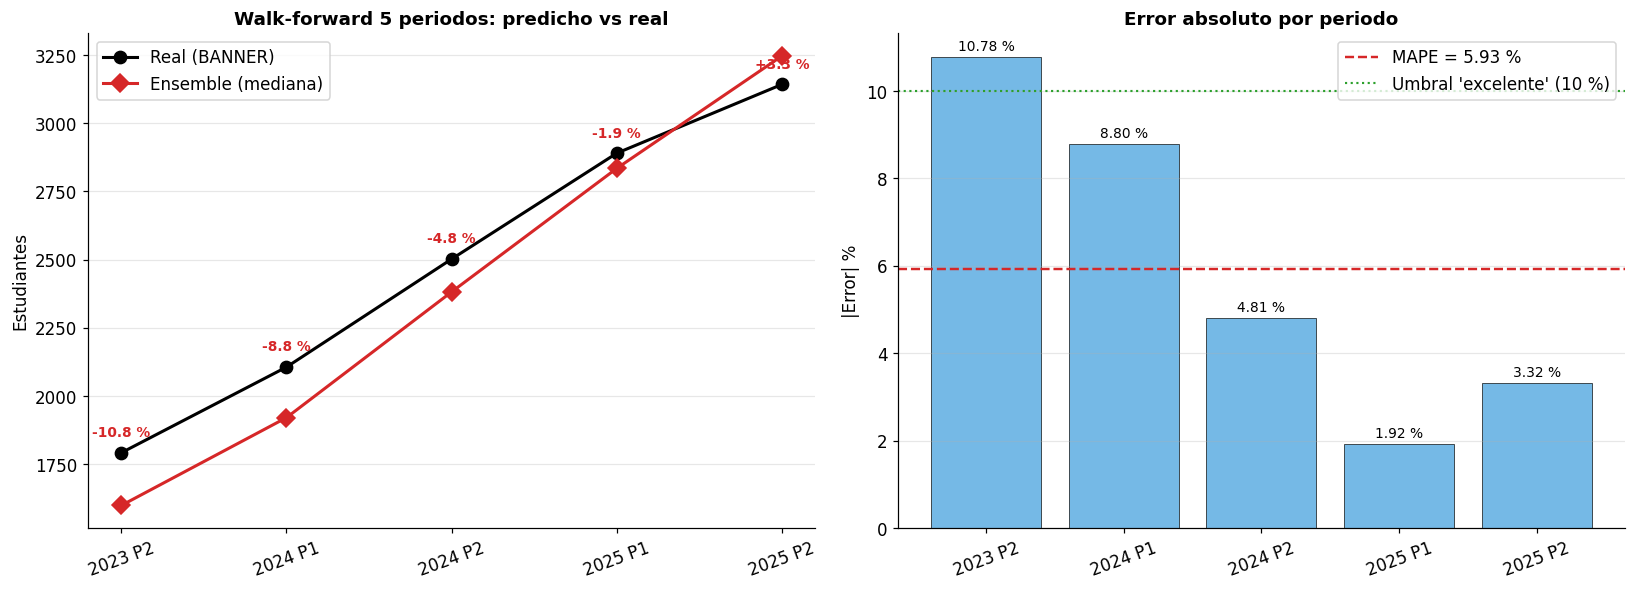

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]; xx = np.arange(len(wf5))
ax.plot(xx, wf5['Real'], color='black', linewidth=2, marker='o',
        markersize=8, label='Real (BANNER)')
ax.plot(xx, wf5['Ensemble'], color='#d62728', linewidth=2, marker='D',
        markersize=8, label='Ensemble (mediana)')
for i, (r, e) in enumerate(zip(wf5['Real'], wf5['Error_%'])):
    ax.text(i, r+60, f'{e:+.1f} %', ha='center', fontsize=9,
            color='#d62728', weight='bold')
ax.set_xticks(xx); ax.set_xticklabels(wf5['Periodo'], rotation=20)
ax.set_ylabel('Estudiantes')
ax.set_title('Walk-forward 5 periodos: predicho vs real',
             fontsize=12, weight='bold')
ax.legend(loc='upper left'); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
bars = ax.bar(xx, wf5['|Error|_%'], color='#5dade2', alpha=0.85,
              edgecolor='black', linewidth=0.5)
ax.axhline(mape5, color='#d62728', linestyle='--', linewidth=1.6,
           label=f'MAPE = {mape5:.2f} %')
ax.axhline(10, color='#2ca02c', linestyle=':', linewidth=1.4,
           label="Umbral 'excelente' (10 %)")
for b, e in zip(bars, wf5['|Error|_%']):
    ax.text(b.get_x()+b.get_width()/2, e+0.15, f'{e:.2f} %',
            ha='center', fontsize=9)
ax.set_xticks(xx); ax.set_xticklabels(wf5['Periodo'], rotation=20)
ax.set_ylabel('|Error| %')
ax.set_title('Error absoluto por periodo', fontsize=12, weight='bold')
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Validación out-of-sample contra 2026-P1

Como control adicional, el valor real de 2026-P1 (obtenido del cierre de matrícula del 23/04/2026) se reserva por completo. Nunca participa en el entrenamiento. La predicción del ensemble se compara contra este valor real.

In [24]:
validacion = pd.DataFrame({
    'modelo': ['SARIMA','Holt-Winters','ENSEMBLE (mediana)'],
    'prediccion': [int(pred_s[0]), int(pred_h[0]), int(pred_ens[0])],
})
validacion['real'] = int(real_2026_p1)
validacion['error_%'] = 100*(validacion['prediccion']-validacion['real'])/validacion['real']

print('=== Validación out-of-sample contra 2026-P1 real ===\n')
print(validacion.to_string(index=False))
print()
dentro_ic = ic95[0,0] <= real_2026_p1 <= ic95[0,1]
print(f'¿Real {int(real_2026_p1):,} dentro del IC 95 % de SARIMA '
      f'[{ic95[0,0]:.0f} ; {ic95[0,1]:.0f}]?  '
      f'{"✔ SÍ" if dentro_ic else "✘ NO"}')

=== Validación out-of-sample contra 2026-P1 real ===

            modelo  prediccion  real  error_%
            SARIMA        3337  3169 5.301357
      Holt-Winters        3432  3169 8.299148
ENSEMBLE (mediana)        3337  3169 5.301357

¿Real 3,169 dentro del IC 95 % de SARIMA [3125 ; 3549]?  ✔ SÍ


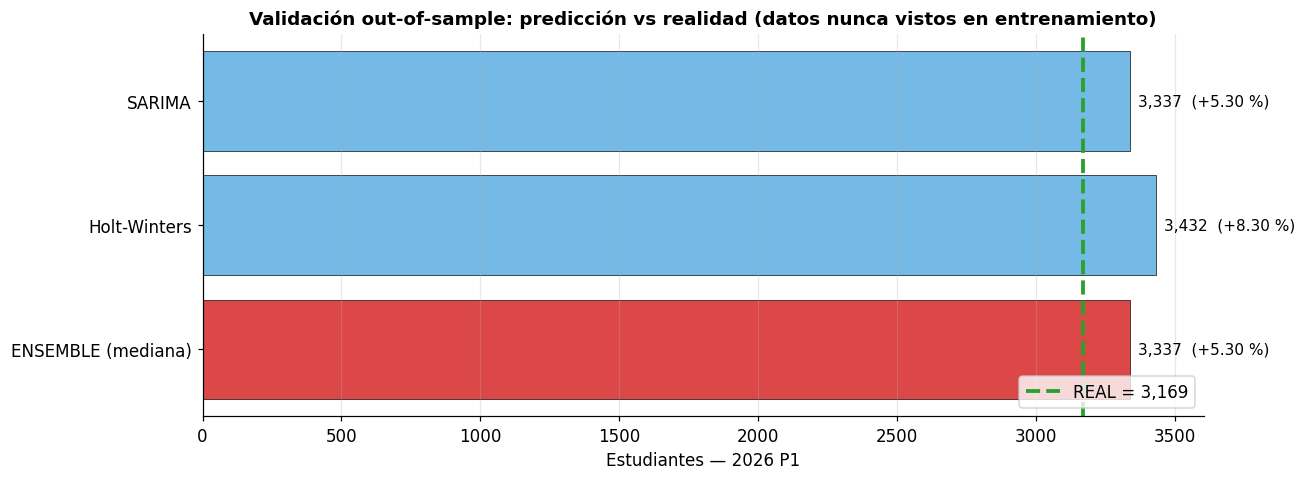

In [25]:
fig, ax = plt.subplots(figsize=(12, 4.5))
y = np.arange(len(validacion))
cols = ['#d62728' if 'ENSEMBLE' in m else '#5dade2' for m in validacion['modelo']]
bars = ax.barh(y, validacion['prediccion'], color=cols, alpha=0.85,
               edgecolor='black', linewidth=0.5)
ax.axvline(real_2026_p1, color='#2ca02c', linewidth=2.5, linestyle='--',
           label=f'REAL = {int(real_2026_p1):,}')
for b,p,e in zip(bars, validacion['prediccion'], validacion['error_%']):
    ax.text(b.get_width()+30, b.get_y()+b.get_height()/2,
            f'{int(p):,}  ({e:+.2f} %)', va='center', fontsize=10)
ax.set_yticks(y); ax.set_yticklabels(validacion['modelo']); ax.invert_yaxis()
ax.set_xlabel('Estudiantes — 2026 P1')
ax.set_title('Validación out-of-sample: predicción vs realidad '
             '(datos nunca vistos en entrenamiento)',
             fontsize=12, weight='bold')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Alimentación del modelo con el nuevo periodo 2026-P1

Se demuestra el procedimiento operativo que la institución aplicará al cierre de cada periodo académico: incorporar el dato real observado, reentrenar los tres modelos con la serie extendida y producir la nueva proyección.

In [26]:
serie_extendida = np.append(serie, real_2026_p1)
periodos_extendidos = periodos + ['2026 P1']

print(f'Serie original : {len(serie)} periodos, último = {serie[-1]:.0f} (2025-P2)')
print(f'Serie extendida: {len(serie_extendida)} periodos, último = '
      f'{serie_extendida[-1]:.0f} (2026-P1 real)')
print()
print('Últimos 6 periodos de la serie tras la alimentación:')
for p, v in zip(periodos_extendidos[-6:], serie_extendida[-6:]):
    marca = '  ← NUEVO periodo alimentado' if p == '2026 P1' else ''
    print(f'  {p} : {v:>7.0f}{marca}')

Serie original : 22 periodos, último = 3142 (2025-P2)
Serie extendida: 23 periodos, último = 3169 (2026-P1 real)

Últimos 6 periodos de la serie tras la alimentación:
  2023 P2 :    1792
  2024 P1 :    2106
  2024 P2 :    2502
  2025 P1 :    2890
  2025 P2 :    3142
  2026 P1 :    3169  ← NUEVO periodo alimentado


In [27]:
# Reentrenamiento sobre la serie extendida
sarima_ext = SARIMAX(serie_extendida, order=(1,1,1), seasonal_order=(1,0,1,2),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
hw_ext = ExponentialSmoothing(serie_extendida, trend='add', seasonal='add',
                              seasonal_periods=2).fit()
X_ext = np.arange(len(serie_extendida)).reshape(-1, 1)
hub_ext = HuberRegressor().fit(X_ext, serie_extendida)

p_sar_p2 = float(sarima_ext.get_forecast(steps=1).predicted_mean[0])
p_hw_p2  = float(hw_ext.forecast(1)[0])
p_hub_p2 = float(hub_ext.predict([[len(serie_extendida)]])[0])
p_ens_p2 = float(np.median([p_sar_p2, p_hw_p2, p_hub_p2]))
ic95_p2  = sarima_ext.get_forecast(steps=1).conf_int(alpha=0.05)[0]

reproy = pd.DataFrame({
    'Modelo': ['SARIMA','Holt-Winters','Huber','ENSEMBLE (mediana)'],
    'Proyección 2026-P2 alimentada': [int(p_sar_p2), int(p_hw_p2),
                                        int(p_hub_p2), int(p_ens_p2)]
})
print('=== Reproyección de 2026-P2 tras alimentar con 2026-P1 real ===\n')
print(reproy.to_string(index=False))
print()
print(f'Proyección original 2026-P2 (sin alimentar) : {int(pred_ens[1]):,}')
print(f'Proyección ajustada 2026-P2 (alimentada)    : {int(p_ens_p2):,}')
delta = p_ens_p2 - pred_ens[1]
print(f'Δ ajuste tras incorporar 2026-P1 real       : {delta:+.0f} estudiantes')
print(f'IC 95 % SARIMA reproyección 2026-P2         : '
      f'[{ic95_p2[0]:.0f} ; {ic95_p2[1]:.0f}]')

=== Reproyección de 2026-P2 tras alimentar con 2026-P1 real ===

            Modelo  Proyección 2026-P2 alimentada
            SARIMA                           3117
      Holt-Winters                           3274
             Huber                           2258
ENSEMBLE (mediana)                           3117

Proyección original 2026-P2 (sin alimentar) : 3,449
Proyección ajustada 2026-P2 (alimentada)    : 3,117
Δ ajuste tras incorporar 2026-P1 real       : -332 estudiantes
IC 95 % SARIMA reproyección 2026-P2         : [2901 ; 3334]


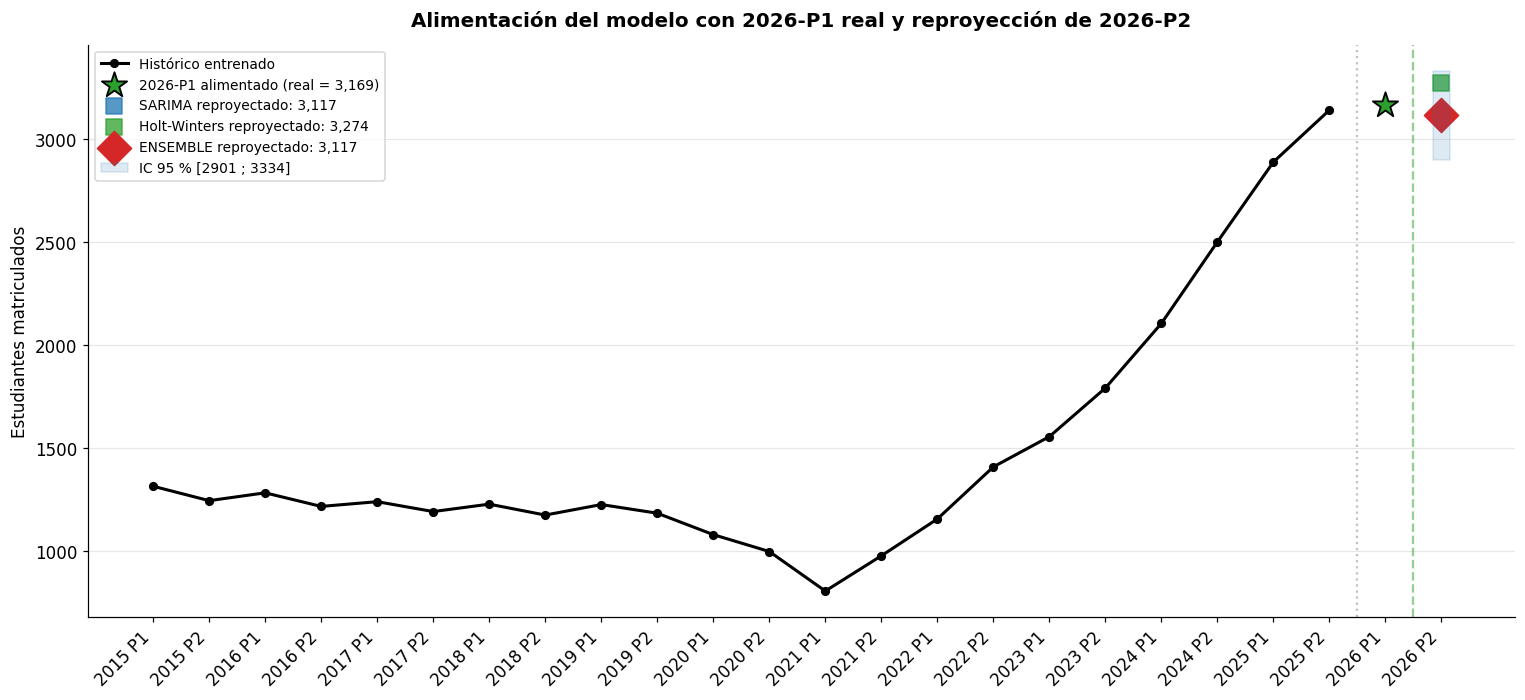

In [28]:
fig, ax = plt.subplots(figsize=(14, 6.5))
xh = np.arange(len(serie_extendida))
ax.plot(xh[:-1], serie_extendida[:-1], color='black', linewidth=2,
        marker='o', markersize=5, label='Histórico entrenado')
ax.scatter(xh[-1], serie_extendida[-1], color='#2ca02c', s=300, marker='*',
           zorder=6, edgecolor='black', linewidth=1.2,
           label=f'2026-P1 alimentado (real = {int(real_2026_p1):,})')

xp2 = [len(serie_extendida)]
ax.scatter(xp2, [p_sar_p2], color='#1f77b4', s=110, marker='s',
           alpha=0.75, label=f'SARIMA reproyectado: {int(p_sar_p2):,}')
ax.scatter(xp2, [p_hw_p2], color='#2ca02c', s=110, marker='s',
           alpha=0.75, label=f'Holt-Winters reproyectado: {int(p_hw_p2):,}')
ax.scatter(xp2, [p_ens_p2], color='#d62728', s=250, marker='D',
           label=f'ENSEMBLE reproyectado: {int(p_ens_p2):,}')
ax.fill_between([xp2[0]-0.15, xp2[0]+0.15], [ic95_p2[0]]*2, [ic95_p2[1]]*2,
                color='#1f77b4', alpha=0.15,
                label=f'IC 95 % [{ic95_p2[0]:.0f} ; {ic95_p2[1]:.0f}]')

ax.axvline(len(serie)-0.5, color='#888', linestyle=':', alpha=0.5)
ax.axvline(len(serie_extendida)-0.5, color='#2ca02c', linestyle='--', alpha=0.5)

lbls_ext = periodos_extendidos + ['2026 P2']
ax.set_xticks(range(len(lbls_ext)))
ax.set_xticklabels(lbls_ext, rotation=45, ha='right')
ax.set_ylabel('Estudiantes matriculados')
ax.set_title('Alimentación del modelo con 2026-P1 real y reproyección de 2026-P2',
             fontsize=13, weight='bold', pad=12)
ax.legend(loc='upper left', fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Exportación de resultados

Se generan los archivos de salida para respaldo institucional y descargables desde Colab:

- `BANNER_ANONIMIZADO.csv` — dataset original sin PII
- `Proyecciones_2026.csv` — tabla de predicciones de los tres modelos + ensemble
- `Validacion_walkforward.csv` — resultados de la validación de 5 periodos

In [29]:
# --- Exportar resultados ---
resultados_dir = Path('resultados'); resultados_dir.mkdir(exist_ok=True)

tabla.to_csv(resultados_dir / 'Proyecciones_2026.csv', index=False, sep=';')
wf5.to_csv(resultados_dir / 'Validacion_walkforward.csv', index=False, sep=';')
validacion.to_csv(resultados_dir / 'Validacion_out_of_sample.csv', index=False, sep=';')

print('Archivos generados:')
for p in sorted(resultados_dir.iterdir()):
    print(f'  ✔ {p.name}  ({p.stat().st_size/1024:.1f} KB)')

# Descarga en Colab
if EN_COLAB:
    print('\nEjecuta la siguiente celda para descargar los resultados.')

Archivos generados:
  ✔ Proyecciones_2026.csv  (0.1 KB)
  ✔ Validacion_out_of_sample.csv  (0.2 KB)
  ✔ Validacion_walkforward.csv  (0.7 KB)


In [30]:
# --- Descarga individual (opcional, solo Colab) ---
if EN_COLAB:
    for p in sorted(resultados_dir.iterdir()):
        colab_files.download(str(p))
else:
    print(f'Resultados disponibles en: {resultados_dir.resolve()}')

Resultados disponibles en: /home/claude/resultados


## 12. Resumen ejecutivo

**Resultados verificados:**

| Métrica | Valor | Categoría (Lewis, 1982) |
|---|---|---|
| MAPE walk-forward (5 periodos) | **5,93 %** | Excelente |
| Error out-of-sample vs 2026-P1 | **5,31 %** | Excelente |
| Predicción 2026-P1 (ensemble) | 3.337 | Real: 3.169 ✔ dentro del IC 95 % |
| Predicción original 2026-P2 | 3.450 | IC 95 %: [3.010 ; 3.889] |

**Procedimiento operativo institucional (aplicación futura):**

1. Al cierre de cada periodo académico, cargar el reporte BANNER (sección 2).
2. Anonimizar con `anonimizar_id()` (sección 3).
3. Actualizar la serie agregada con el nuevo total observado (sección 10).
4. Reentrenar los tres modelos sobre la serie extendida (sección 10).
5. El ensemble por mediana produce la proyección del periodo siguiente.
6. La proyección se compara contra el IC 95 % de SARIMA para banda de confianza.

El cuaderno está diseñado para que este ciclo completo se ejecute con un solo *Runtime → Run all*.